# 03. Машинное обучение: прогноз низкой оценки (1–2★)

**Задача:** бинарная классификация `target = 1`, если клиент поставит 1–2 звезды (порог обоснован в ноутбуке 02).

**План:**
1. Признаки из SQL-витрины `order_features` + несколько производных.
2. Честное разбиение **по времени**: учимся на прошлом, проверяем на будущем.
3. Выбор метрики с учётом дисбаланса классов (12,8% положительных).
4. Базовые решения: случайный прогноз и бизнес-правило «все опоздавшие заказы».
5. Три модели: логистическая регрессия, случайный лес, градиентный бустинг, одинаковая кросс-валидация.
6. Выбор порога под бизнес-сценарий.
7. Интерпретация: какие факторы важнее всего и что это значит для бизнеса.

### Подготовка окружения (локально или Google Colab)
В Colab ячейка подключит Google Drive и перейдёт в папку проекта: при необходимости поправьте путь `PROJECT_DIR`.
Локально (Jupyter / VS Code) ячейка просто определит пути.

In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = "/content/drive/MyDrive/olist-capstone"   # <- папка проекта на Google Drive
    os.chdir(PROJECT_DIR)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
# В Colab базу кладём на локальный диск машины (так быстрее и надёжнее, чем на Drive).
# Каждая сессия Colab начинается с чистой машины, поэтому база при необходимости пересобирается (~1 мин).
DB_PATH = Path("/content/olist.db") if IN_COLAB else ROOT / "data" / "olist.db"
print("Папка проекта:", ROOT)
print("База данных:  ", DB_PATH)

Папка проекта: /home/claude/olist-capstone
База данных:   /home/claude/olist-capstone/data/olist.db


In [2]:
import sqlite3
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA, VIOLET, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#b5b3ad", "#52514e"
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 100,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRAY, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 1. Данные и признаки

In [3]:
if not DB_PATH.exists():          # база ещё не собрана (например, новая сессия Colab)
    from build_database import build
    build(DB_PATH)
con = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM order_features", con, parse_dates=["order_purchase_timestamp"])
con.close()
df = df.sort_values("order_purchase_timestamp").reset_index(drop=True)

# Целевая переменная (обоснование порога — ноутбук 02)
df["target"] = (df["review_score"] <= 2).astype(int)

# Производные признаки
lat1, lon1, lat2, lon2 = (np.radians(df[c]) for c in ["customer_lat", "customer_lng", "seller_lat", "seller_lng"])
df["distance_km"] = 6371 * 2 * np.arcsin(np.sqrt(
    np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2))
df["is_new_seller"] = df["seller_prior_low_rate"].isna().astype(int)       # нет истории отзывов
df["card_incomplete"] = df["avg_photos_qty"].isna().astype(int)            # у товара нет карточки/категории

CAT_FEATURES = ["category", "payment_type", "customer_state", "seller_state"]
NUM_FEATURES = [
    # сроки и логистика
    "delivery_days", "estimated_days", "delay_days", "is_late", "approval_hours",
    "seller_handling_days", "carrier_days", "seller_missed_limit",
    "purchase_month", "purchase_dow", "purchase_hour",
    # состав заказа и товар
    "n_items", "n_products", "n_sellers", "items_price", "freight_value",
    "freight_ratio", "total_weight_g", "total_volume_cm3", "avg_photos_qty", "avg_description_len",
    "card_incomplete",
    # оплата
    "max_installments", "n_payments", "n_payment_types",
    # продавец и география
    "same_state", "distance_km", "seller_prior_orders", "seller_prior_reviews",
    "seller_prior_low_rate", "is_new_seller",
]
FEATURES = CAT_FEATURES + NUM_FEATURES
# payment_value (≈ items_price + freight_value) и max_item_price почти дублируют items_price:
# их убираем, чтобы коэффициенты логистической регрессии были интерпретируемы (мультиколлинеарность)
print(f"Признаков: {len(FEATURES)} ({len(CAT_FEATURES)} категориальных, {len(NUM_FEATURES)} числовых)")
print("Столбцы review_* в признаках:", [c for c in FEATURES if "review" in c], "-> только история продавца ДО покупки")

Признаков: 35 (4 категориальных, 31 числовых)
Столбцы review_* в признаках: ['seller_prior_reviews'] -> только история продавца ДО покупки


**Контроль утечки.** В признаки не попадают текст отзыва, даты создания и ответа на отзыв, сама оценка.
Всё, что связано с продавцом (`seller_prior_*`), посчитано в SQL строго по событиям **до даты покупки**.
Сроки доставки известны в момент доставки, а именно этот момент задан в бизнес-вопросе.

## 2. Разбиение по времени

Случайное разбиение «подсмотрело» бы будущее: модель видела бы соседние по времени заказы тех же продавцов в тот же сезон.
Реалистичный сценарий: обучаемся на истории и применяем к новым заказам. Поэтому:
* **train** — заказы, купленные до 1 июня 2018 (≈ 81%);
* **test** — заказы июня–августа 2018 (≈ 19%), в подборе параметров не участвуют.

In [4]:
SPLIT_DATE = "2018-06-01"
is_train = df["order_purchase_timestamp"] < SPLIT_DATE
X_train, y_train = df.loc[is_train, FEATURES], df.loc[is_train, "target"]
X_test, y_test = df.loc[~is_train, FEATURES], df.loc[~is_train, "target"]

split_info = pd.DataFrame({
    "период": [f"{df.loc[is_train, 'order_purchase_timestamp'].min():%Y-%m} … 2018-05",
               f"2018-06 … {df.loc[~is_train, 'order_purchase_timestamp'].max():%Y-%m}"],
    "заказов": [len(y_train), len(y_test)],
    "доля 1–2★, %": [round(y_train.mean() * 100, 1), round(y_test.mean() * 100, 1)],
    "доля опозданий, %": [round(X_train["is_late"].mean() * 100, 1), round(X_test["is_late"].mean() * 100, 1)],
}, index=["train", "test"])
split_info

,период,заказов,"доля 1–2★, %","доля опозданий, %"
train,2016-09 … 2018-05,77304,13.5,7.4
test,2018-06 … 2018-08,18520,9.7,3.5


В тестовом периоде доля недовольных ниже (9,7% против 13,5%): летом 2018 было меньше опозданий (см. EDA, раздел 9).
Это усложняет задачу, потому что модель проверяется в условиях, отличных от обучения. Зато оценка получается честной.
Дополнительная оговорка: в данных есть заказы до конца августа 2018, и часть поздних заказов этого месяца ещё не была доставлена на момент выгрузки.

## 3. Выбор метрики

* **Accuracy не подходит:** модель «все клиенты довольны» даст 90% accuracy на тесте и не найдёт ни одного недовольного.
* **Основная метрика — PR-AUC (average precision).** Она оценивает, насколько хорошо модель ранжирует заказы по риску,
  и сосредоточена именно на редком классе. Случайная модель получает PR-AUC, равный доле класса (≈ 0,10 на тесте), поэтому видно реальный выигрыш.
* **Дополнительно:** ROC-AUC (общая способность разделять классы), а при выбранном пороге — **precision** (доля реально недовольных среди тех, кому мы позвоним)
  и **recall** (какую долю всех недовольных мы нашли).
* Бизнес-смысл: у службы поддержки ограниченный ресурс. Важно, чтобы в первых N% заказов по риску было как можно больше реально недовольных клиентов,
  и PR-AUC измеряет ровно это.

## 4. Базовые решения (baselines)

Прежде чем строить модели, зафиксируем, что даёт отсутствие модели и простое бизнес-правило.

In [5]:
results = []


def evaluate(name, y_true, score, y_pred=None):
    row = {"model": name,
           "PR-AUC": average_precision_score(y_true, score),
           "ROC-AUC": roc_auc_score(y_true, score)}
    if y_pred is not None:
        row.update({"precision": precision_score(y_true, y_pred, zero_division=0),
                    "recall": recall_score(y_true, y_pred),
                    "F1": f1_score(y_true, y_pred)})
    return row


dummy = DummyClassifier(strategy="prior").fit(X_train, y_train)
results.append(evaluate("Baseline: без модели", y_test, dummy.predict_proba(X_test)[:, 1], dummy.predict(X_test)))

rule = X_test["is_late"].values          # правило: «звоним всем, чей заказ опоздал»
results.append(evaluate("Baseline: правило «опоздал»", y_test, rule, rule))
pd.DataFrame(results).set_index("model").round(3)

,PR-AUC,ROC-AUC,precision,recall,F1
model,,,,,
Baseline: без модели,0.097,0.500,0.000,0.00,0.00
Baseline: правило «опоздал»,0.160,0.575,0.468,0.17,0.25


**Вывод.** Правило «опоздал → риск» — сильный и понятный ориентир: почти половина опоздавших заказов (47%) действительно получает 1–2★.
Но правило находит лишь **17%** недовольных клиентов тестового периода: остальные 83% получили заказ вовремя, и правило их не видит.
Модель должна (а) найти этих клиентов по другим сигналам и (б) ранжировать заказы по степени риска, а не просто делить на «да/нет».

## 5. Модели

| Модель | Почему выбрана | Предобработка |
|---|---|---|
| **Логистическая регрессия** | интерпретируемый линейный baseline, коэффициенты = отношения шансов | log1p для денег/веса, стандартизация, one-hot для категорий, `class_weight="balanced"` |
| **Random Forest** | нелинейные зависимости и взаимодействия, устойчив к выбросам | one-hot, заполнение медианой, `class_weight="balanced_subsample"` |
| **Gradient Boosting** (`HistGradientBoostingClassifier`) | обычно лучший алгоритм на табличных данных, сам обрабатывает пропуски и категории | ordinal-кодирование категорий |

Все пропуски заполняются **внутри пайплайна**: статистики считаются только на обучающих фолдах.

In [6]:
SKEWED = ["items_price", "freight_value", "total_weight_g", "total_volume_cm3",
          "seller_prior_orders", "seller_prior_reviews", "distance_km", "approval_hours"]
OTHER_NUM = [c for c in NUM_FEATURES if c not in SKEWED]


def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


ohe = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=200, sparse_output=False)

logreg = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", ohe)]), CAT_FEATURES),
        ("skew", Pipeline([("imp", SimpleImputer(strategy="median")),
                           ("log", FunctionTransformer(signed_log1p, feature_names_out="one-to-one")), ("sc", StandardScaler())]), SKEWED),
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), OTHER_NUM),
    ])),
    ("model", LogisticRegression(C=0.1, class_weight="balanced", max_iter=3000)),
])

forest = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", clone(ohe))]), CAT_FEATURES),
        ("num", SimpleImputer(strategy="median"), NUM_FEATURES),
    ])),
    ("model", RandomForestClassifier(n_estimators=250, min_samples_leaf=20, max_features="sqrt",
                                     class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)),
])

boosting = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                               encoded_missing_value=-1), CAT_FEATURES),
        ("num", "passthrough", NUM_FEATURES),
    ])),
    ("model", HistGradientBoostingClassifier(
        categorical_features=list(range(len(CAT_FEATURES))), learning_rate=0.05, max_iter=400,
        max_leaf_nodes=31, min_samples_leaf=50, l2_regularization=1.0, random_state=RANDOM_STATE)),
])

MODELS = {"Logistic Regression": logreg, "Random Forest": forest, "Gradient Boosting": boosting}

### 5.1 Подбор гиперпараметров

Кросс-валидация по времени (`TimeSeriesSplit`, 4 фолда) **только на train**: каждый фолд обучается на прошлом и проверяется на следующем периоде.
Метрика подбора — PR-AUC. Небольшие сетки подобраны так, чтобы расчёт занимал несколько минут.

In [7]:
cv = TimeSeriesSplit(n_splits=4)

grids = {
    "Logistic Regression": [{"model__C": c} for c in (0.01, 0.1, 1.0)],
    "Random Forest": [{"model__min_samples_leaf": l, "model__max_features": f}
                      for l in (10, 30) for f in ("sqrt", 0.3)],
    "Gradient Boosting": [{"model__learning_rate": lr, "model__max_leaf_nodes": n}
                          for lr in (0.03, 0.08) for n in (15, 31)],
}

tuning_rows, best_params = [], {}
for name, pipe in MODELS.items():
    best = None
    for params in grids[name]:
        t0 = time.time()
        cvres = cross_validate(clone(pipe).set_params(**params), X_train, y_train, cv=cv,
                               scoring={"pr_auc": "average_precision", "roc_auc": "roc_auc"}, n_jobs=1)
        row = {"model": name, "params": params,
               "CV PR-AUC": cvres["test_pr_auc"].mean(), "CV PR-AUC std": cvres["test_pr_auc"].std(),
               "CV ROC-AUC": cvres["test_roc_auc"].mean(), "sec": round(time.time() - t0)}
        tuning_rows.append(row)
        if best is None or row["CV PR-AUC"] > best["CV PR-AUC"]:
            best = row
    best_params[name] = best["params"]

tuning = pd.DataFrame(tuning_rows)
tuning.assign(params=tuning["params"].astype(str)).round(4)

,model,params,CV PR-AUC,CV PR-AUC std,CV ROC-AUC,sec
0,Logistic Regression,{'model__C': 0.01},0.4572,0.1141,0.7665,4
1,Logistic Regression,{'model__C': 0.1},0.4545,0.1156,0.7640,5
2,Logistic Regression,{'model__C': 1.0},0.4538,0.1161,0.7634,5
3,Random Forest,"{'model__min_samples_leaf': 10, 'model__max_features': 'sqrt'}",0.4836,0.1236,0.7705,53
4,Random Forest,"{'model__min_samples_leaf': 10, 'model__max_features': 0.3}",0.4846,0.1206,0.7696,119
5,Random Forest,"{'model__min_samples_leaf': 30, 'model__max_features': 'sqrt'}",0.4819,0.1225,0.7712,44
6,Random Forest,"{'model__min_samples_leaf': 30, 'model__max_features': 0.3}",0.4877,0.1198,0.7718,110
7,Gradient Boosting,"{'model__learning_rate': 0.03, 'model__max_leaf_nodes': 15}",0.4897,0.1215,0.7720,4
8,Gradient Boosting,"{'model__learning_rate': 0.03, 'model__max_leaf_nodes': 31}",0.4880,0.1209,0.7706,5
9,Gradient Boosting,"{'model__learning_rate': 0.08, 'model__max_leaf_nodes': 15}",0.4899,0.1223,0.7707,2


In [8]:
best_cv = tuning.loc[tuning.groupby("model")["CV PR-AUC"].idxmax()].set_index("model")
best_cv[["params", "CV PR-AUC", "CV PR-AUC std", "CV ROC-AUC"]].round(4)

,params,CV PR-AUC,CV PR-AUC std,CV ROC-AUC
model,,,,
Gradient Boosting,"{'model__learning_rate': 0.08, 'model__max_leaf_nodes': 15}",0.4899,0.1223,0.7707
Logistic Regression,{'model__C': 0.01},0.4572,0.1141,0.7665
Random Forest,"{'model__min_samples_leaf': 30, 'model__max_features': 0.3}",0.4877,0.1198,0.7718


### 5.2 Финальное обучение на всём train и проверка на отложенном тесте

In [9]:
fitted, test_scores = {}, {}
for name, pipe in MODELS.items():
    model = clone(pipe).set_params(**best_params[name]).fit(X_train, y_train)
    fitted[name] = model
    test_scores[name] = model.predict_proba(X_test)[:, 1]
    results.append(evaluate(name, y_test, test_scores[name]))

comparison = pd.DataFrame(results).set_index("model")
comparison = comparison.join(best_cv[["CV PR-AUC", "CV PR-AUC std"]])
comparison[["CV PR-AUC", "CV PR-AUC std", "PR-AUC", "ROC-AUC"]].rename(
    columns={"PR-AUC": "test PR-AUC", "ROC-AUC": "test ROC-AUC"}).round(3)

,CV PR-AUC,CV PR-AUC std,test PR-AUC,test ROC-AUC
model,,,,
Baseline: без модели,NaN,NaN,0.097,0.500
Baseline: правило «опоздал»,NaN,NaN,0.160,0.575
Logistic Regression,0.457,0.114,0.287,0.707
Random Forest,0.488,0.120,0.322,0.711
Gradient Boosting,0.490,0.122,0.320,0.711


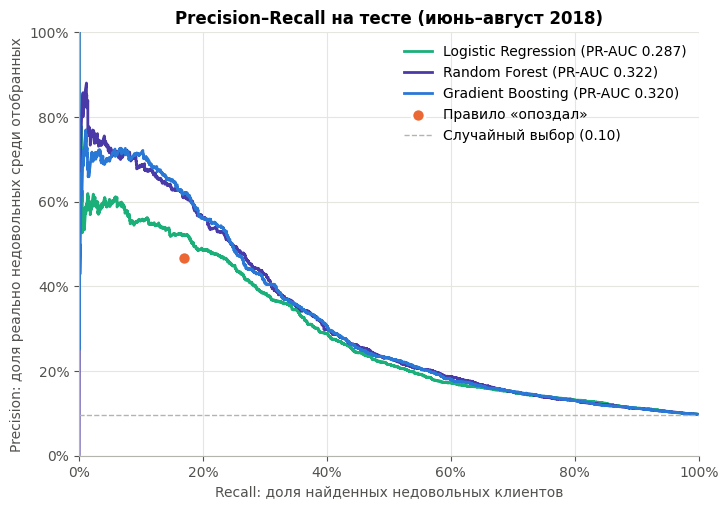

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = {"Logistic Regression": AQUA, "Random Forest": VIOLET, "Gradient Boosting": BLUE}
for name, score in test_scores.items():
    p, r, _ = precision_recall_curve(y_test, score)
    ax.plot(r, p, lw=2, color=colors[name], label=f"{name} (PR-AUC {average_precision_score(y_test, score):.3f})")
rule_row = comparison.loc["Baseline: правило «опоздал»"]
ax.scatter(rule_row["recall"], rule_row["precision"], s=90, color=ORANGE, zorder=5,
           edgecolor="white", linewidth=2, label="Правило «опоздал»")
ax.axhline(y_test.mean(), color=GRAY, ls="--", lw=1, label=f"Случайный выбор ({y_test.mean():.2f})")
ax.set_xlabel("Recall: доля найденных недовольных клиентов")
ax.set_ylabel("Precision: доля реально недовольных среди отобранных")
ax.set_title("Precision–Recall на тесте (июнь–август 2018)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="upper right")
save(fig, "12_pr_curves")
plt.show()

**Вывод по сравнению моделей.**
* **Все три модели намного лучше базовых решений:** test PR-AUC 0,29–0,32 против 0,10 у случайного выбора и 0,16 у правила «опоздал».
  По всей кривой precision–recall модели лежат выше точки правила.
* **Бустинг и случайный лес фактически равны:** CV PR-AUC 0,490 и 0,488, test 0,320 и 0,322. Разница много меньше разброса между фолдами (std ≈ 0,12),
  то есть статистически это ничья.
* **Логистическая регрессия заметно слабее** (CV 0,457, test 0,287), особенно в левой части кривой, где отбираются самые рискованные заказы.
  Причина — пороговый эффект опоздания: до обещанной даты риск почти не меняется, после неё резко растёт (EDA, раздел 4). Линейная модель такую «ступеньку» описывает плохо.
* **Финальный выбор — Gradient Boosting.** Он лучший по кросс-валидации (выбор по тесту был бы подгонкой под тест). Кроме того, он обучается примерно в 20 раз быстрее леса
  (2–5 с против 50–120 с), сам обрабатывает пропуски и, поскольку обучен без весов классов, выдаёт вероятности, близкие к реальной частоте. Их можно читать как «риск недовольства».
* **Почему PR-AUC на тесте ниже, чем на CV.** PR-AUC зависит от доли положительного класса: в тестовом периоде недовольных меньше (9,7% против ~13,5%).
  В относительных величинах картина стабильна: модель превосходит случайный выбор примерно в 3,3–3,5 раза и на CV, и на тесте.
* ROC-AUC ≈ 0,71 — умеренное качество, и это честный результат: часть недовольства связана с качеством самого товара, которого нет в структурированных данных.

## 6. Выбор порога под бизнес-сценарий

Модель выдаёт вероятность недовольства. Порог выбираем не по умолчанию (0,5), а от **ресурса поддержки**:
сколько заказов в день команда может обработать проактивно (звонок, извинение, промокод).
Сравним сценарии «обрабатываем топ-5% / 10% / 20% заказов по риску» с правилом «звоним всем опоздавшим».

In [11]:
# Модель выбираем по кросс-валидации на train, а НЕ по тесту (иначе тест перестаёт быть независимым)
best_name = best_cv["CV PR-AUC"].idxmax()
best_score = test_scores[best_name]
print("Лучшая модель по CV PR-AUC:", best_name)

rows = []
base_rate = y_test.mean()
for share in (0.05, 0.068, 0.10, 0.20):
    thr = np.quantile(best_score, 1 - share)
    pred = (best_score >= thr).astype(int)
    rows.append({"сценарий": f"модель: топ-{share:.0%} по риску" if share != 0.068 else "модель: столько же заказов, сколько опоздало",
                 "порог вероятности": round(thr, 3),
                 "заказов в работу": int(pred.sum()),
                 "precision": precision_score(y_test, pred), "recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred), "lift": precision_score(y_test, pred) / base_rate})
rows.append({"сценарий": "правило: все опоздавшие", "порог вероятности": np.nan, "заказов в работу": int(rule.sum()),
             "precision": precision_score(y_test, rule), "recall": recall_score(y_test, rule),
             "F1": f1_score(y_test, rule), "lift": precision_score(y_test, rule) / base_rate})
scenarios = pd.DataFrame(rows).set_index("сценарий")
scenarios.round(3)

Лучшая модель по CV PR-AUC: Gradient Boosting


,порог вероятности,заказов в работу,precision,recall,F1,lift
сценарий,,,,,,
модель: топ-5% по риску,0.266,926,0.486,0.250,0.330,4.994
"модель: столько же заказов, сколько опоздало",0.211,1260,0.423,0.296,0.348,4.348
модель: топ-10% по риску,0.167,1852,0.350,0.360,0.355,3.596
модель: топ-20% по риску,0.105,3704,0.234,0.482,0.315,2.408
правило: все опоздавшие,NaN,656,0.468,0.170,0.250,4.810


Порог по максимуму F1 = 0.167: precision = 0.350, recall = 0.360, в работу 10.0% заказов


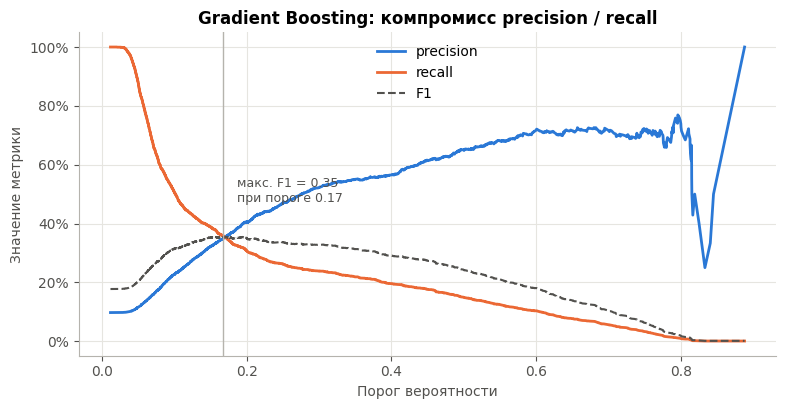

In [12]:
p, r, thr = precision_recall_curve(y_test, best_score)
f1 = 2 * p * r / (p + r + 1e-12)
best_i = np.nanargmax(f1[:-1])
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(thr, p[:-1], color=BLUE, lw=2, label="precision")
ax.plot(thr, r[:-1], color=ORANGE, lw=2, label="recall")
ax.plot(thr, f1[:-1], color=INK, lw=1.5, ls="--", label="F1")
ax.axvline(thr[best_i], color=GRAY, lw=1)
ax.annotate(f"макс. F1 = {f1[best_i]:.2f}\nпри пороге {thr[best_i]:.2f}", (thr[best_i], f1[best_i]),
            textcoords="offset points", xytext=(10, 25), fontsize=9, color=INK)
ax.set_xlabel("Порог вероятности"); ax.set_ylabel("Значение метрики")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title(f"{best_name}: компромисс precision / recall")
ax.legend(frameon=False)
save(fig, "13_threshold")
plt.show()
f1_pred = (best_score >= thr[best_i]).astype(int)
print(f"Порог по максимуму F1 = {thr[best_i]:.3f}: precision = {p[best_i]:.3f}, recall = {r[best_i]:.3f}, "
      f"в работу {f1_pred.mean():.1%} заказов")

**Выбор порога.** Максимум F1 достигается при пороге ≈ 0,17, это почти ровно **топ-10% заказов по риску**. Рекомендуемый рабочий режим:
* в работу поддержки попадает 10% доставленных заказов (≈ 1 850 за 3 месяца теста, **~20 заказов в день**);
* **35%** из них реально поставили бы 1–2★. Это в 3,6 раза выше случайного выбора;
* найдено **36%** всех недовольных клиентов, **вдвое больше**, чем даёт правило «опоздал» (17%).

**Модель лучше правила при любом ресурсе.** При том же объёме работы, что у правила (6,8% заказов), модель находит 30% недовольных против 17% с почти той же точностью (42% против 47%).
Топ-5% по модели даёт даже большую точность, чем правило (49% против 47%), и при этом больший охват (25% против 17%).

Порог — бизнес-решение, зависящее от стоимости действия:
* **дешёвое действие** (письмо с извинением, промокод) → можно расширить до топ-20%: охват 48%, precision 23%;
* **дорогое действие** (звонок менеджера, компенсация) → топ-5%: каждый второй контакт по делу.

## 7. Интерпретация: что сильнее всего влияет на прогноз

### 7.1 Permutation importance лучшей модели
Перемешиваем значения одного признака на тесте и смотрим, насколько падает PR-AUC. Чем сильнее падение, тем важнее признак.
Этот метод не зависит от типа модели и считается на отложенных данных.

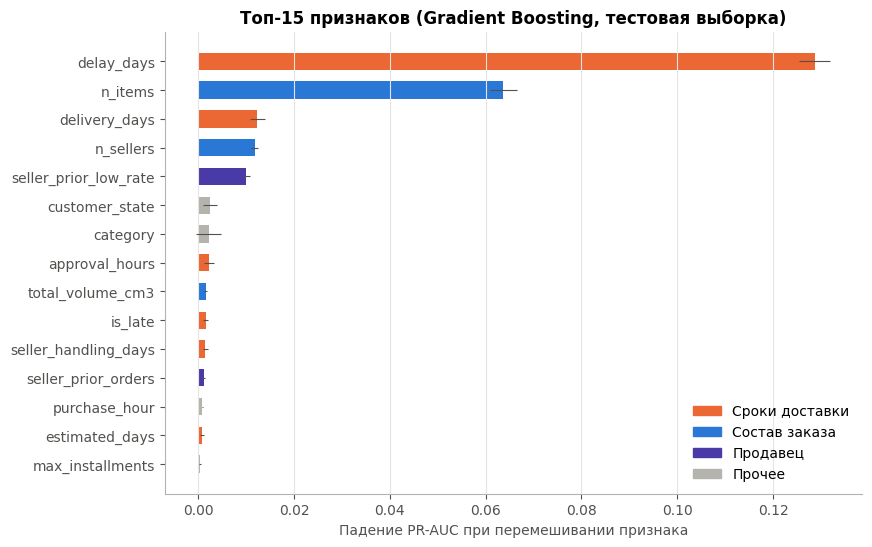

,feature,importance,std
0,delay_days,0.1287,0.0033
1,n_items,0.0637,0.0027
2,delivery_days,0.0124,0.0017
3,n_sellers,0.0118,0.0008
4,seller_prior_low_rate,0.0101,0.0007
5,customer_state,0.0025,0.0015
6,category,0.0022,0.0026
7,approval_hours,0.0022,0.0011
8,total_volume_cm3,0.0015,0.0004
9,is_late,0.0015,0.0006


In [13]:
best_model = fitted[best_name]
perm = permutation_importance(best_model, X_test, y_test, scoring="average_precision",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
imp = (pd.DataFrame({"feature": FEATURES, "importance": perm.importances_mean, "std": perm.importances_std})
         .sort_values("importance", ascending=False).reset_index(drop=True))
top = imp.head(15).iloc[::-1]

GROUPS = {
    "Сроки доставки": ["delivery_days", "estimated_days", "delay_days", "is_late", "carrier_days",
                       "seller_handling_days", "seller_missed_limit", "approval_hours"],
    "Состав заказа": ["n_items", "n_products", "n_sellers", "items_price", "freight_value",
                      "freight_ratio", "total_weight_g", "total_volume_cm3"],
    "Продавец": ["seller_prior_low_rate", "seller_prior_orders", "seller_prior_reviews", "is_new_seller", "seller_state"],
}
def group_of(f):
    return next((g for g, cols in GROUPS.items() if f in cols), "Прочее")
gcol = {"Сроки доставки": ORANGE, "Состав заказа": BLUE, "Продавец": VIOLET, "Прочее": GRAY}

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["importance"], xerr=top["std"], color=[gcol[group_of(f)] for f in top["feature"]],
        height=0.6, error_kw={"ecolor": INK, "lw": 0.8})
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=g) for g, c in gcol.items()], frameon=False, loc="lower right")
ax.set_xlabel("Падение PR-AUC при перемешивании признака")
ax.set_title(f"Топ-15 признаков ({best_name}, тестовая выборка)")
ax.grid(axis="y", visible=False)
save(fig, "14_permutation_importance")
plt.show()
imp.head(15).round(4)

In [14]:
imp["group"] = imp["feature"].map(group_of)
imp.groupby("group")["importance"].sum().sort_values(ascending=False).round(4).to_frame("суммарная важность")

,суммарная важность
group,
Сроки доставки,0.1466
Состав заказа,0.0748
Продавец,0.0112
Прочее,0.0055


### 7.2 Направление влияния: коэффициенты логистической регрессии
Логистическая регрессия почти не уступает бустингу и даёт понятную интерпретацию: `exp(коэффициент)` — во сколько раз меняются шансы низкой оценки
при росте признака на одно стандартное отклонение (для числовых признаков после масштабирования).

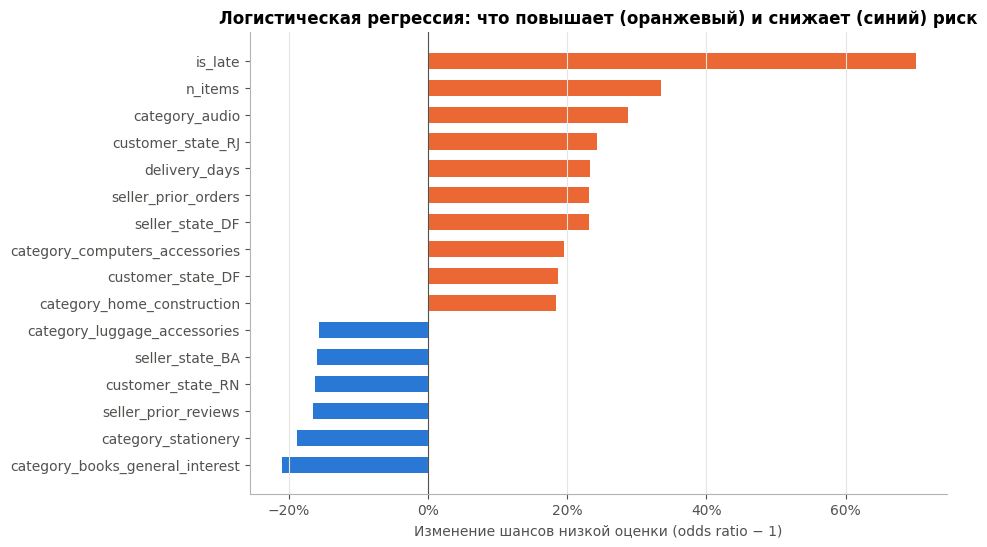

,feature,coef,odds_ratio
88,is_late,0.531,1.701
95,n_items,0.289,1.335
1,category_audio,0.253,1.288
56,customer_state_RJ,0.218,1.243
85,delivery_days,0.209,1.233
81,seller_prior_orders,0.208,1.232
66,seller_state_DF,0.208,1.231
6,category_computers_accessories,0.179,1.196
44,customer_state_DF,0.171,1.187
21,category_home_construction,0.169,1.184


In [15]:
lr_model = fitted["Logistic Regression"]
names = lr_model.named_steps["prep"].get_feature_names_out()
coefs = pd.DataFrame({"feature": names, "coef": lr_model.named_steps["model"].coef_[0]})
coefs["odds_ratio"] = np.exp(coefs["coef"])
coefs["feature"] = coefs["feature"].str.replace(r"^(cat|skew|num)__", "", regex=True)
coef_top = pd.concat([coefs.nlargest(10, "coef"), coefs.nsmallest(6, "coef")]).sort_values("coef")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_top["feature"], coef_top["odds_ratio"] - 1,
        color=[ORANGE if v > 0 else BLUE for v in coef_top["coef"]], height=0.6)
ax.axvline(0, color=INK, lw=0.8)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Изменение шансов низкой оценки (odds ratio − 1)")
ax.set_title("Логистическая регрессия: что повышает (оранжевый) и снижает (синий) риск")
ax.grid(axis="y", visible=False)
save(fig, "15_logreg_odds")
plt.show()
coef_top.sort_values("coef", ascending=False).round(3)

### 7.3 Как прогноз зависит от ключевых факторов
Средний прогноз модели при разных значениях признака (остальные признаки — как в реальных заказах). Это аналог partial dependence, выраженный в вероятности.

Опоздание: -10 дн -> 9.8%, 0 -> 13.8%, +4 -> 54.4%, +10 -> 74.2%
Продавцов 1/2/3: [0.095 0.127 0.127]
Репутация 0% / 20% / 40%: [0.088 0.107 0.14 ]


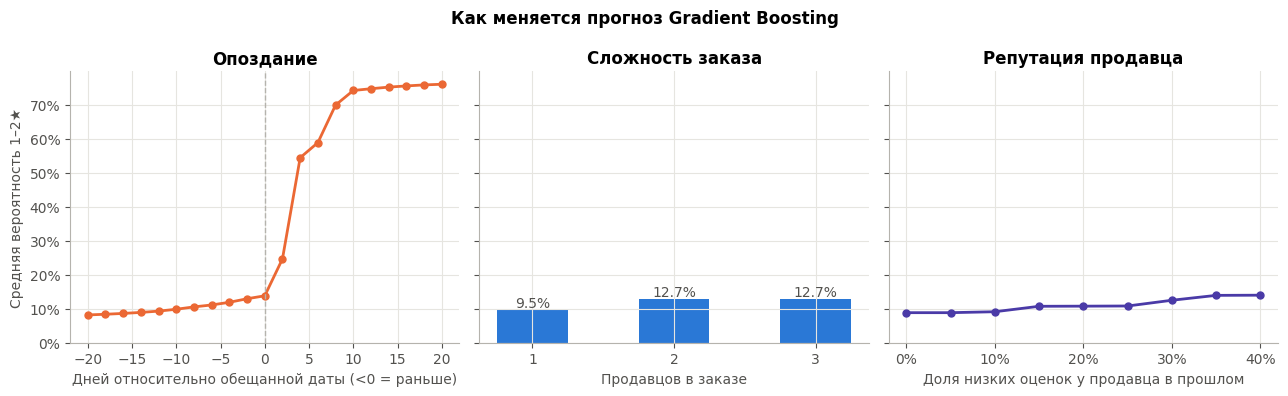

In [16]:
def avg_prediction(model, X, feature, values):
    out = []
    Xc = X.copy()
    for v in values:
        Xc[feature] = v
        out.append(model.predict_proba(Xc)[:, 1].mean())
    return np.array(out)

sample = X_test.sample(4000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

delays = np.arange(-20, 21, 2)
s = sample.copy()
pd_delay = []
for d in delays:
    s["delay_days"] = d
    s["is_late"] = int(d > 0)
    s["delivery_days"] = (sample["estimated_days"] + d).clip(lower=1)
    pd_delay.append(best_model.predict_proba(s)[:, 1].mean())
axes[0].plot(delays, pd_delay, color=ORANGE, lw=2, marker="o", ms=5)
axes[0].axvline(0, color=GRAY, ls="--", lw=1)
axes[0].set_xlabel("Дней относительно обещанной даты (<0 = раньше)")
axes[0].set_title("Опоздание")

sellers = [1, 2, 3]
pd_sellers = avg_prediction(best_model, sample, "n_sellers", sellers)
bars = axes[1].bar([str(v) for v in sellers], pd_sellers, color=BLUE, width=0.5)
for b_, v in zip(bars, pd_sellers):
    axes[1].text(b_.get_x() + b_.get_width() / 2, v + 0.01, f"{v:.1%}", ha="center", color=INK)
axes[1].set_xlabel("Продавцов в заказе"); axes[1].set_title("Сложность заказа")

rates = np.linspace(0, 0.4, 9)
pd_rep = avg_prediction(best_model, sample, "seller_prior_low_rate", rates)
axes[2].plot(rates, pd_rep, color=VIOLET, lw=2, marker="o", ms=5)
axes[2].set_xticks([0, 0.1, 0.2, 0.3, 0.4])
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
axes[2].set_xlabel("Доля низких оценок у продавца в прошлом"); axes[2].set_title("Репутация продавца")

axes[0].set_ylabel("Средняя вероятность 1–2★")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
fig.suptitle(f"Как меняется прогноз {best_name}", fontweight="bold")
fig.tight_layout()
save(fig, "16_effects")
plt.show()
print("Опоздание: -10 дн -> {:.1%}, 0 -> {:.1%}, +4 -> {:.1%}, +10 -> {:.1%}".format(
    pd_delay[list(delays).index(-10)], pd_delay[list(delays).index(0)], pd_delay[list(delays).index(4)],
    pd_delay[list(delays).index(10)]))
print("Продавцов 1/2/3:", np.round(pd_sellers, 3))
print("Репутация 0% / 20% / 40%:", np.round(pd_rep[[0, 4, 8]], 3))

**Что влияет на прогноз (в переводе на язык бизнеса).**

1. **Опоздание относительно обещанной даты — фактор №1** (около 60% всей важности модели приходится на группу «сроки доставки»).
   При доставке на 10 дней раньше срока модель оценивает риск в 10%, в день обещанной даты — в 14%,
   **при опоздании на 4 дня — уже в 54%**, на 10 дней — в 74%. Риск растёт скачком сразу после обещанной даты, поэтому **первые 2–4 дня опоздания — решающее окно** для вмешательства.
2. **Сложность заказа — фактор №2** (около 30% важности): число товаров и число продавцов. При прочих равных каждое дополнительное стандартное отклонение числа товаров
   повышает шансы низкой оценки на 34% (логистическая регрессия). Заказ из нескольких посылок = больше точек отказа.
3. **Репутация продавца.** При росте доли прошлых низких оценок продавца с 0% до 40% риск нового заказа растёт с 9% до 14%.
   Проблемные продавцы повторяют ошибки, поэтому историю продавца стоит учитывать при приоритизации.
4. **Фактический срок доставки** важен и сам по себе: даже без опоздания очень долгая доставка раздражает.
5. **Второстепенные факторы:** штат клиента (RJ +24% к шансам), категории (аудио, компьютерные аксессуары — выше риск; книги, канцелярия — ниже).
6. **Практически не влияют:** способ оплаты, цена, вес, время покупки. Недовольство — это вопрос **исполнения заказа**, а не того, что и как купили.

*Примечание к коэффициентам:* логистическая регрессия показывает изменение шансов при росте признака на одно стандартное отклонение.
Признаки `seller_prior_orders` и `seller_prior_reviews` сильно коррелируют (оба — «размер» продавца), поэтому их коэффициенты надо читать вместе, а не по отдельности.

## 8. Дополнительно: можно ли предупредить риск ещё раньше?

Бизнесу выгоднее узнать о риске **до** доставки, пока посылка в пути. Обучим тот же бустинг только на признаках,
известных в момент передачи заказа перевозчику: без фактической даты доставки, задержки и времени в пути.

In [17]:
EARLY_DROP = ["delivery_days", "delay_days", "is_late", "carrier_days"]
early_features = [f for f in FEATURES if f not in EARLY_DROP]
early_num = [f for f in NUM_FEATURES if f not in EARLY_DROP]
early_model = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                               encoded_missing_value=-1), CAT_FEATURES),
        ("num", "passthrough", early_num),
    ])),
    ("model", clone(boosting.named_steps["model"]).set_params(
        **{k.replace("model__", ""): v for k, v in best_params["Gradient Boosting"].items()})),
]).fit(X_train[early_features], y_train)
early_score = early_model.predict_proba(X_test[early_features])[:, 1]
early = pd.DataFrame([
    evaluate("Ранний прогноз (при отгрузке)", y_test, early_score),
    evaluate(f"{best_name} (в момент доставки)", y_test, best_score),
]).set_index("model")[["PR-AUC", "ROC-AUC"]]
top10 = lambda s: y_test.values[s >= np.quantile(s, 0.9)].mean()
early["precision в топ-10%"] = [top10(early_score), top10(best_score)]
early.round(3)

,PR-AUC,ROC-AUC,precision в топ-10%
model,,,
Ранний прогноз (при отгрузке),0.224,0.658,0.262
Gradient Boosting (в момент доставки),0.320,0.711,0.350


**Вывод.** Даже **до доставки**, в момент передачи заказа перевозчику, модель различает рискованные заказы: PR-AUC 0,22 (в 2,3 раза лучше случайного),
в топ-10% каждый четвёртый заказ — будущая низкая оценка. Это слабее, чем прогноз в момент доставки (0,32), но даёт время **предотвратить** проблему, а не только сгладить её.
Практическая схема — **двухэтапная:** при отгрузке — превентивные меры (приоритетная доставка, честное обновление даты), при доставке или опоздании — проактивный контакт с клиентом.

## 9. Итоги и бизнес-выводы

**Ответ на бизнес-вопрос.** Да, предсказать низкую оценку до того, как клиент её поставит, можно, но **частично**.
Модель (Gradient Boosting) на данных, известных в момент доставки, выделяет группу риска:
в топ-10% заказов по прогнозу 35% клиентов реально ставят 1–2★ (в 3,6 раза выше среднего), и эта группа содержит 36% всех недовольных, **в два раза больше**, чем простое правило «заказ опоздал».
Значительную часть недовольства модель не видит: его причины (качество товара, несоответствие описанию) не отражены в структурированных данных.

**Рекомендации для Olist:**
1. **Ежедневный список риска:** ~20 заказов в день с наибольшей вероятностью недовольства → проактивное извинение или промокод до того, как клиент поставит оценку.
2. **Триггер по опозданию:** первые 2–4 дня после обещанной даты — критическое окно; автоматическое уведомление клиента в этот момент.
3. **Честная дата доставки:** длинный обещанный срок почти не снижает оценку, а нарушенный — снижает резко. Выгоднее закладывать запас в обещанную дату.
4. **Заказы от нескольких продавцов:** предупреждать клиента о раздельной доставке, по возможности консолидировать отправку.
5. **Контроль продавцов с плохой историей** и продавцов, срывающих срок отгрузки: это ранний сигнал, доступный ещё до доставки.

**Ограничения:**
* тестовый период (лето 2018) отличается от обучающего меньшей долей опозданий; модель нужно регулярно переобучать;
* модель находит связи, а не причины; эффект вмешательства (станет ли клиент довольнее после извинения) нужно проверять A/B-тестом;
* текст отзывов по условиям проекта не использовался.

**Что можно улучшить:** история покупок клиента (повторные клиенты), калибровка вероятностей, SHAP-анализ, отдельная модель для раннего прогноза при отгрузке.